In [1]:
import os
import sys
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

/tmp/ipykernel_32231/4228124591.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
substrates = ["autogrid", "cryochip", "newSiChip", "si_old_chip"]
velocities = ["0.2", "0.5", "1", "1.5"]
#data_archive_path = os.environ['THESIS_DATA_ARCHIVE_PATH']
data_archive_path = "/home/abharadwaj1/thesis/data_archive"
parent_folder_path = os.path.join(data_archive_path, "inputs", "5_vitrification", "analyse_cavity_closing", "relative_depth_at_closure")
plot_output_folder = os.path.join(data_archive_path, "figures_output", "5_vitrification", "relative_depths_at_close")
assert os.path.exists(parent_folder_path), f"Parent folder path does not exist: {parent_folder_path}"
assert os.path.exists(plot_output_folder), f"Plot output folder does not exist: {plot_output_folder}"
def get_result_file(substrate):
    substrate_folder = os.path.join(parent_folder_path, substrate)
    result_file = [f for f in os.listdir(substrate_folder) if f.endswith(".csv")][0]
    return os.path.join(substrate_folder, result_file)
def get_image_files(substrate):
    substrate_folder = os.path.join(parent_folder_path, substrate)
    image_files = [os.path.join(substrate_folder, f) for f in os.listdir(substrate_folder) if f.endswith(".png") and "detect" not in f]
    # parse images based on velocity
    images_by_velocity = {v: [] for v in velocities}
    for image_file in image_files:
        for v in velocities:
            if f"{v}mps" in image_file:
                images_by_velocity[v].append(image_file)
    # drop keys with no images
    images_by_velocity = {k: v for k, v in images_by_velocity.items() if len(v) > 0}
    # print number of images for each velocity
    for v, files in images_by_velocity.items():
        print(f"Velocity {v} m/s: {len(files)} images")
    return images_by_velocity
def get_surface_image_files(substrate):
    surface_images_folder = os.path.join(parent_folder_path, "surface_level", substrate)
    surface_image_files = [os.path.join(surface_images_folder, f) for f in os.listdir(surface_images_folder) if f.endswith(".png")]
    # parse images based on velocity
    surface_images_by_velocity = {v: [] for v in velocities}
    for image_file in surface_image_files:
        for v in velocities:
            if f"{v}mps" in image_file:
                surface_images_by_velocity[v].append(image_file)
    # drop keys with no images
    surface_images_by_velocity = {k: v for k, v in surface_images_by_velocity.items() if len(v) > 0}
    # print number of surface images for each velocity
    for v, files in surface_images_by_velocity.items():
        print(f"Surface Velocity {v} m/s: {len(files)} images")
    return surface_images_by_velocity

substrate_folders = {substrate : os.path.join(parent_folder_path, substrate) for substrate in substrates}
image_files_by_velocity = {substrate : get_image_files(substrate) for substrate in substrates}
surface_image_files_by_velocity = {substrate : get_surface_image_files(substrate) for substrate in substrates}
csv_results_files = {substrate : get_result_file(substrate) for substrate in substrates}


Velocity 0.2 m/s: 3 images
Velocity 0.5 m/s: 3 images
Velocity 1 m/s: 8 images
Velocity 0.2 m/s: 1 images
Velocity 0.5 m/s: 3 images
Velocity 1 m/s: 10 images
Velocity 1.5 m/s: 4 images
Velocity 1 m/s: 4 images
Velocity 0.5 m/s: 5 images
Velocity 1 m/s: 8 images
Surface Velocity 0.2 m/s: 3 images
Surface Velocity 0.5 m/s: 3 images
Surface Velocity 1 m/s: 8 images
Surface Velocity 0.2 m/s: 1 images
Surface Velocity 0.5 m/s: 3 images
Surface Velocity 1 m/s: 10 images
Surface Velocity 1.5 m/s: 4 images
Surface Velocity 1 m/s: 4 images
Surface Velocity 0.5 m/s: 5 images
Surface Velocity 1 m/s: 8 images


In [3]:
# read grayscale images from image paths 
def read_images(image_file):
    img = plt.imread(image_file)
    if img.ndim == 3:  # Convert RGB to grayscale if necessary
        img = np.mean(img, axis=2)
    
    return img

In [4]:
# match images with surface images 
matched_images = {} 
for substrate, images_by_velocity in image_files_by_velocity.items():
    matched_images[substrate] = {}
    for velocity, images in images_by_velocity.items():
        matched_images[substrate][velocity] = {}
        surface_level_images = surface_image_files_by_velocity[substrate][velocity]
        for trial, image in enumerate(images):
            # find the corresponding surface image
            image_timestamp = "_".join(image.split("_")[3:5])
            surface_image_with_same_first_part = [s for s in surface_level_images if image_timestamp in s][0]
            matched_images[substrate][velocity][trial] = {
                "image" : read_images(image),
                "surface_level_image": read_images(surface_image_with_same_first_part),
                "image_filename" : image,
                "surface_image_filename": surface_image_with_same_first_part
            }



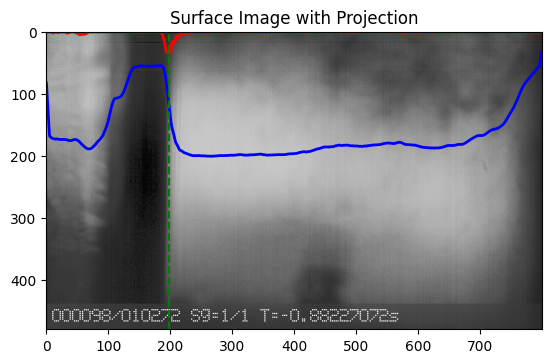

In [5]:
random_substrate = np.random.choice(substrates)
random_velocity = np.random.choice(list(image_files_by_velocity[random_substrate].keys()))
random_trial = np.random.choice(list(matched_images[random_substrate][random_velocity].keys()))
test_surface_image = matched_images[random_substrate][random_velocity][random_trial]["surface_level_image"]
#plt.imshow(test_surface_image)
#projection_y = np.mean(test_surface_image, axis=0)
projection_y = np.percentile(test_surface_image, 97, axis=0)
uniform_filter_size = 10
projection_y = np.convolve(projection_y, np.ones(uniform_filter_size)/uniform_filter_size, mode='same')
gradient_projection_y = np.gradient(projection_y)
positive_gradients = gradient_projection_y >= 0
negative_gradients = gradient_projection_y < 0
gradients_filtered = np.zeros_like(gradient_projection_y)
gradients_filtered[negative_gradients] = 0
gradients_filtered[positive_gradients] = gradient_projection_y[positive_gradients]
gradients_filtered[:10] = 0
surface_level_detected = np.argmax(gradients_filtered)

# show the projection above the image with hte exact same dimensions
plt.imshow(test_surface_image, cmap='gray')
plt.plot(abs(gradients_filtered)*1000, color='red', linewidth=2)
plt.plot(projection_y*255, color='blue', linewidth=2)
plt.title("Surface Image with Projection")
plt.axvline(surface_level_detected, color='green', linestyle='--', label='Detected Surface Level')
    

In [6]:
def detect_surface_level(image):
    projection_y = np.percentile(image, 97, axis=0)
    uniform_filter_size = 10
    projection_y = np.convolve(projection_y, np.ones(uniform_filter_size)/uniform_filter_size, mode='same')
    gradient_projection_y = np.gradient(projection_y)
    positive_gradients = gradient_projection_y >= 0
    negative_gradients = gradient_projection_y < 0
    gradients_filtered = np.zeros_like(gradient_projection_y)
    gradients_filtered[negative_gradients] = 0
    gradients_filtered[positive_gradients] = gradient_projection_y[positive_gradients]
    gradients_filtered[:10] = 0
    surface_level_detected = np.argmax(gradients_filtered)
    return surface_level_detected, gradients_filtered, projection_y


In [7]:
# Save the detected surface levels to a CSV file
output_csv_file = os.path.join(parent_folder_path, "detected_surface_levels.csv")
# detected_surface_level_df = pd.DataFrame.from_dict({
#     (substrate, velocity, trial): data
#     for substrate, velocities in detected_surface_level.items()
#     for velocity, trials in velocities.items()
#     for trial, data in trials.items()
# }, orient='index').reset_index()
# detected_surface_level_df.columns = ['substrate', 'velocity', 'trial', 'surface_level_detected', 'gradients_filtered', 'projection_y']
# detected_surface_level_df.to_csv(output_csv_file, index=False)

# read the CSV files and plot the results
detected_surface_level_df = pd.read_csv(output_csv_file)
detected_surface_level = {}
for substrate in substrates:
    detected_surface_level[substrate] = {}
    for velocity in velocities:
        detected_surface_level[substrate][velocity] = {}
        number_of_trials = len(detected_surface_level_df[
            (detected_surface_level_df['substrate'] == substrate) &
            (detected_surface_level_df['velocity'] == float(velocity))
        ])
        for trial in range(number_of_trials):
            # detected_surface_level[substrate][velocity][trial] = {
            #     "surface_level_detected": detected_surface_level_df['surface_level_detected'][trial],
            #     "gradients_filtered": eval(detected_surface_level_df['gradients_filtered'][trial]),
            #     "projection_y": eval(detected_surface_level_df['projection_y'][trial])
            # }
            try:
                index_in_df = detected_surface_level_df[
                    (detected_surface_level_df['substrate'] == substrate) &
                    (detected_surface_level_df['velocity'] == float(velocity)) &
                    (detected_surface_level_df['trial'] == trial)
                ].index[0]
                detected_surface_level[substrate][velocity][trial] = {
                    "surface_level_detected": detected_surface_level_df['surface_level_detected'][index_in_df],
                    "gradients_filtered": detected_surface_level_df['gradients_filtered'][index_in_df],
                    "projection_y": detected_surface_level_df['projection_y'][index_in_df]
                }
            except IndexError:
                print(f"No data found for {substrate}, {velocity}, trial {trial}. Skipping.")


In [8]:
# extract depth and height from all files 
depth_and_height_data = {}
for substrate in substrates:
    depth_and_height_data[substrate] = {}
    result_file = csv_results_files[substrate]
    df = pd.read_csv(result_file)
    for velocity in matched_images[substrate].keys():
        depth_and_height_data[substrate][velocity] = {}
        for trial in matched_images[substrate][velocity].keys():
            print(f"Processing {substrate} at {velocity} m/s, trial {trial}")
            depth_and_height_data[substrate][velocity][trial] = {}
            image_filename = os.path.basename(matched_images[substrate][velocity][trial]["image_filename"])
            depth_from_results = df[df["Label"] == image_filename]["X"].values[0]
            height_from_results = df[df["Label"] == image_filename]["Height"].values[0]
            width_from_results = df[df["Label"] == image_filename]["Width"].values[0]
            surface_level_detected = detected_surface_level[substrate][velocity][trial]["surface_level_detected"]
            depth_from_surface = depth_from_results - surface_level_detected
            depth_and_height_data[substrate][velocity][trial]["depth_from_results"] = depth_from_results
            depth_and_height_data[substrate][velocity][trial]["height_from_results"] = height_from_results
            depth_and_height_data[substrate][velocity][trial]["width_from_results"] = width_from_results
            depth_and_height_data[substrate][velocity][trial]["depth_from_surface"] = depth_from_surface

            
               

Processing autogrid at 0.2 m/s, trial 0
Processing autogrid at 0.2 m/s, trial 1
Processing autogrid at 0.2 m/s, trial 2
Processing autogrid at 0.5 m/s, trial 0
Processing autogrid at 0.5 m/s, trial 1
Processing autogrid at 0.5 m/s, trial 2
Processing autogrid at 1 m/s, trial 0
Processing autogrid at 1 m/s, trial 1
Processing autogrid at 1 m/s, trial 2
Processing autogrid at 1 m/s, trial 3
Processing autogrid at 1 m/s, trial 4
Processing autogrid at 1 m/s, trial 5
Processing autogrid at 1 m/s, trial 6
Processing autogrid at 1 m/s, trial 7
Processing cryochip at 0.2 m/s, trial 0
Processing cryochip at 0.5 m/s, trial 0
Processing cryochip at 0.5 m/s, trial 1
Processing cryochip at 0.5 m/s, trial 2
Processing cryochip at 1 m/s, trial 0
Processing cryochip at 1 m/s, trial 1
Processing cryochip at 1 m/s, trial 2
Processing cryochip at 1 m/s, trial 3
Processing cryochip at 1 m/s, trial 4
Processing cryochip at 1 m/s, trial 5
Processing cryochip at 1 m/s, trial 6
Processing cryochip at 1 m/s, 

In [9]:
reference_data_diameter = {
    "autogrid" : 3.532e-3,
    "cryochip" : 2e-3,
    "newSiChip" : 3e-3,
    "si_old_chip" : 3.2e-3,
}
reference_data_thickness = {
    "autogrid" : 0.3e-3,
    "cryochip" : 0.1e-3,
    "newSiChip" : 0.2e-3,
    "si_old_chip" : 0.3e-3,
}

calibrated_depth_and_height_data = {}
for substrate, velocities in depth_and_height_data.items():
    calibrated_depth_and_height_data[substrate] = {}
    for velocity, trials in velocities.items():
        calibrated_depth_and_height_data[substrate][velocity] = {}
        for trial, data in trials.items():
            reference_height = reference_data_diameter[substrate] # in meters
            height_from_results = data["height_from_results"] # in pixels
            width_from_results = data["width_from_results"] # in pixels
            pixel_size = reference_height / height_from_results # in meters per pixel
            pixel_anisotropy_correction = 149 / 123 # pixel_height / pixel_width
            pixel_size_along_depth = pixel_size * pixel_anisotropy_correction # in meters per pixel
            calibrated_depth_minimum = data["depth_from_surface"] * pixel_size_along_depth
            uncertainty_in_depth = 2e-3 # in meters
            calibrated_depth_maximum = calibrated_depth_minimum + uncertainty_in_depth
            r = reference_height / 2  
            H_by_r_minimum = calibrated_depth_minimum / r
            H_by_r_maximum = calibrated_depth_maximum / r
            relative_depth = (H_by_r_maximum + H_by_r_minimum) / 2
            relative_depth_range = (H_by_r_maximum - H_by_r_minimum) / 2
            froude_number_diameter = float(velocity) / np.sqrt(9.81 * reference_data_diameter[substrate])
            froude_number_thickness = float(velocity) / np.sqrt(9.81 * reference_data_thickness[substrate])
            calibrated_depth_and_height_data[substrate][velocity][trial] = {
                "H_calibrated_minimum": calibrated_depth_minimum,
                "H_calibrated_maximum": calibrated_depth_maximum,
                "r_calibrated": r,
                "relative_depth": relative_depth,
                "relative_depth_maximum": H_by_r_maximum,
                "froude_number_diameter": froude_number_diameter,
                "froude_number_thickness": froude_number_thickness,
                "relative_depth_minimum": H_by_r_minimum,
                "relative_depth_range": relative_depth_range
            }



In [11]:
# dump calibrated depth and height data to a csv file
output_calibrated_csv_file = os.path.join(parent_folder_path, "calibrated_depth_and_height_data_pixel_anisotropy_corrected.csv")
calibrated_depth_and_height_df = pd.DataFrame.from_dict({
    (substrate, velocity, trial): data
    for substrate, velocities in calibrated_depth_and_height_data.items()
    for velocity, trials in velocities.items()
    for trial, data in trials.items()
    
}, orient='index').reset_index()
calibrated_depth_and_height_df.columns = ['substrate', 'velocity', 'trial', 'calibrated_depth_minimum', 'calibrated_depth_maximum', 'calibrated_height', 'relative_depth', 'relative_depth_maximum', 'froude_number_diameter', 'froude_number_thickness', 'relative_depth_minimum', 'relative_depth_range']
#calibrated_depth_and_height_df.to_csv(output_calibrated_csv_file, index=False)


<ErrorbarContainer object of 3 artists>

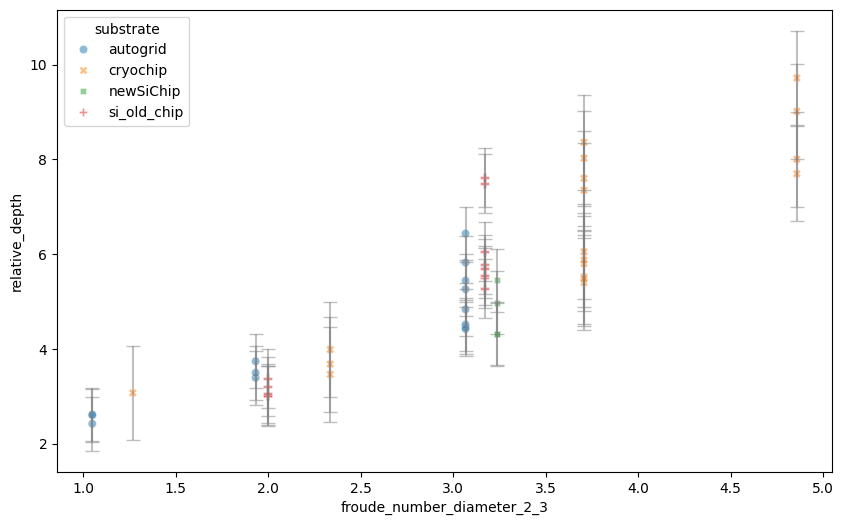

In [12]:
import seaborn as sns
# Plotting the relative depth against Froude number^2/3
calibrated_depth_and_height_df['froude_number_diameter_2_3'] = calibrated_depth_and_height_df['froude_number_diameter'] ** (2/3)
calibrated_depth_and_height_df['froude_number_thickness_2_3'] = calibrated_depth_and_height_df['froude_number_thickness'] ** (2/3)
plt.figure(figsize=(10, 6))
#sns.scatterplot(data=calibrated_depth_and_height_df, x='froude_number_diameter_2_3', y='relative_depth', hue='substrate', style='substrate')
# show scatterplot with maximum and minimum relative depth for each data point 
sns.scatterplot(data=calibrated_depth_and_height_df, x='froude_number_diameter_2_3', y='relative_depth', hue='substrate', style='substrate', alpha=0.5)
# plot the maximum and minimum relative depth as error bars
plt.errorbar(
    calibrated_depth_and_height_df['froude_number_diameter_2_3'],
    calibrated_depth_and_height_df['relative_depth'],
    yerr=calibrated_depth_and_height_df['relative_depth_range'],
    fmt='none',
    capsize=5,
    color='gray',
    alpha=0.5
)




<Axes: xlabel='froude_number_thickness_2_3', ylabel='relative_depth'>

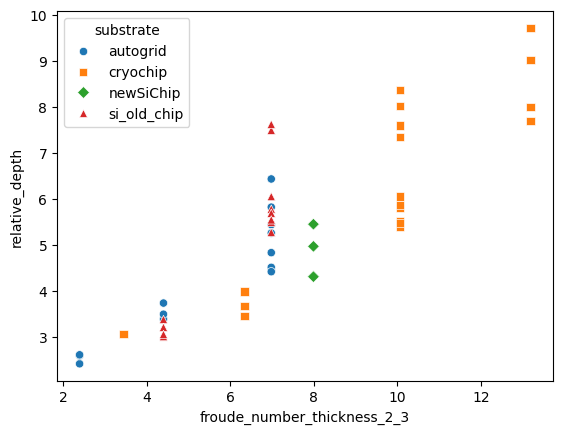

In [13]:
sns.scatterplot(data=calibrated_depth_and_height_df, x='froude_number_thickness_2_3', y='relative_depth', hue='substrate', style='substrate', markers=['o', 's', 'D', '^'])

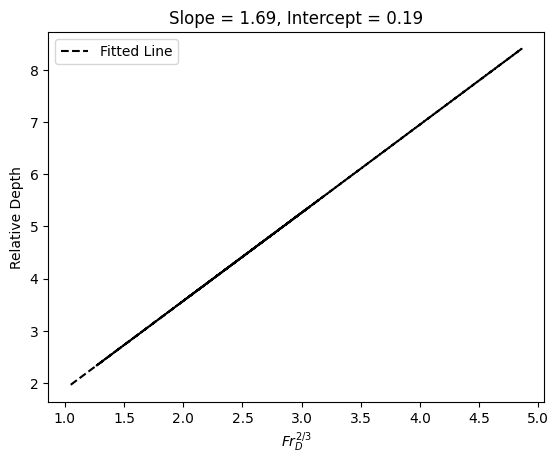

In [14]:
froude_number_diameter_2_3_array = calibrated_depth_and_height_df['froude_number_diameter_2_3'].values
relative_depth_array = calibrated_depth_and_height_df['relative_depth'].values
# Fit a linear regression model to the data
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(froude_number_diameter_2_3_array.reshape(-1, 1), relative_depth_array)
# Predict the relative depth using the fitted model
predicted_relative_depth = model.predict(froude_number_diameter_2_3_array.reshape(-1, 1))
slope_predicted, intercept_predicted = model.coef_[0], model.intercept_
# Plot the fitted line
plt.plot(froude_number_diameter_2_3_array, predicted_relative_depth, color='black', linestyle='--', label='Fitted Line')
plt.xlabel(r'$Fr_{D}^{2/3}$')
plt.ylabel('Relative Depth')
plt.title("Slope = {:.2f}, Intercept = {:.2f}".format(slope_predicted, intercept_predicted))
plt.legend()

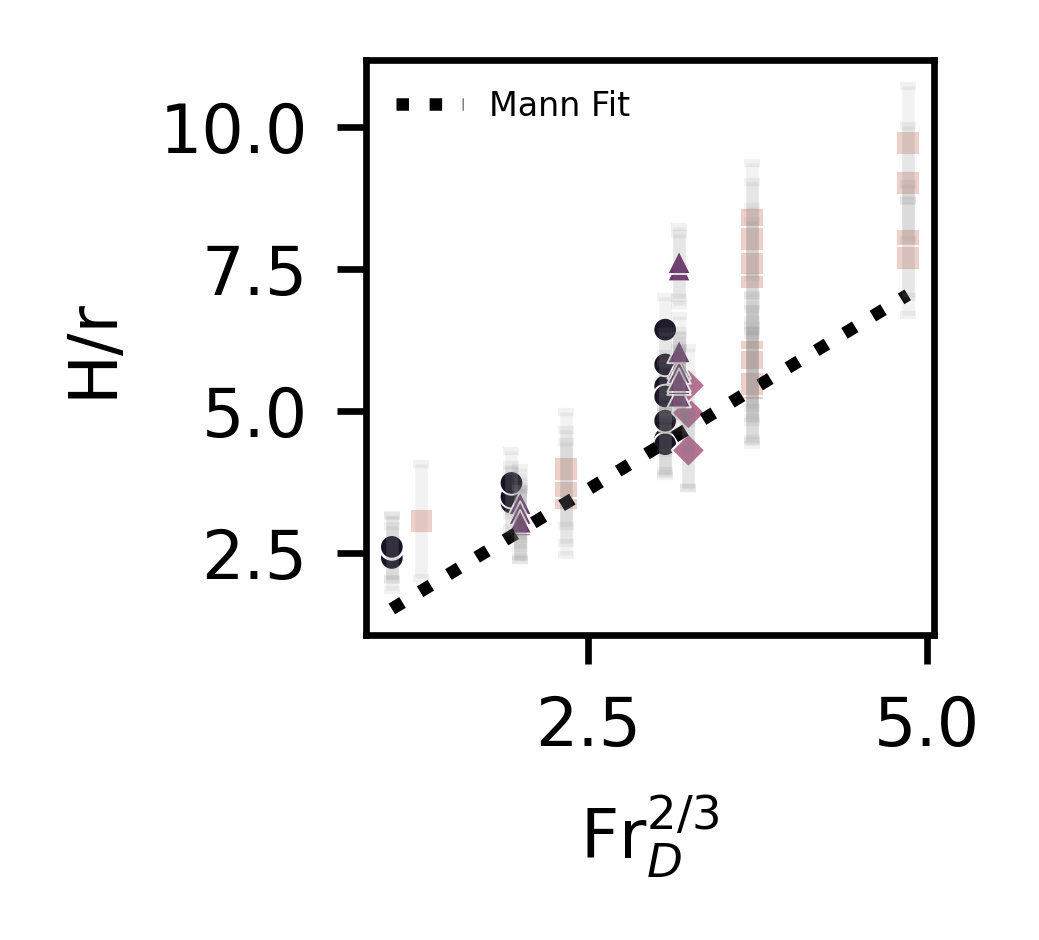

In [16]:
sys.path.append("/home/abharadwaj1/thesis/utils")
from plot_utils import configure_plot_scaling, temporary_rcparams
figsize_mm = (45, 40)
figsize_in = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)  # Convert mm to inches
fontsize = 8
rcParams = configure_plot_scaling(figsize_mm)
rcParams['font.size'] = fontsize

alpha_glasheen = 13.4#.297
alpha_mann = 1.45 
froude_numbers_fit = np.linspace(min(calibrated_depth_and_height_df['froude_number_diameter_2_3']), max(calibrated_depth_and_height_df['froude_number_diameter_2_3']), 100)
# Glasheen and McMahon fit
glasheen_fit = alpha_glasheen * froude_numbers_fit
# Mann fit 
mann_fit = alpha_mann * froude_numbers_fit
#custom_palette = [, , , ]
custom_palette = ["#191125","#edd0ca", "#b77093","#6e346e",]
with temporary_rcparams(rcParams):
    fig, ax = plt.subplots(figsize=figsize_in, dpi=600)

    #ax.plot(froude_numbers_fit, glasheen_fit, color='black', linestyle='-', label='Glasheen & McMahon Fit')
    ax.plot(froude_numbers_fit, mann_fit, color='black', linestyle=':', label='Mann Fit')
    sns.scatterplot(data=calibrated_depth_and_height_df, x='froude_number_diameter_2_3', y='relative_depth', \
                    hue='substrate', palette=custom_palette, style='substrate', markers=['o', 's', 'D', '^'], ax=ax, legend=False, s=8, alpha=1)
    # plot error bars for maximum and minimum relative depth
    ax.errorbar(
        calibrated_depth_and_height_df['froude_number_diameter_2_3'],
        calibrated_depth_and_height_df['relative_depth'],
        yerr=calibrated_depth_and_height_df['relative_depth_range'],
        fmt='none',
        capsize=1,
        color='gray',
        alpha=0.1
    )
    #ax.set_yscale('log')
    ax.set_yticks([2.5, 5, 7.5, 10])
    ax.set_xticks([2.5, 5])

    ax.legend(loc='upper left', fontsize=4, frameon=False)
    fig.tight_layout()
    ax.set_xlabel('Fr$^{2/3}_D$')
    ax.set_ylabel('H/r')
    fig_save_path = os.path.join(plot_output_folder, "relative_depth_vs_froude_number_diameter_anisotropy_corrected.pdf")
    fig.savefig(fig_save_path, bbox_inches='tight')


In [17]:
data_archive_folder = "/home/abharadwaj1/thesis/data_archive/"
output_folder = os.path.join(data_archive_folder, "figures_output", "5_vitrification", "relative_depths_at_close")
assert os.path.exists(output_folder), f"Output folder {output_folder} does not exist."

In [18]:
# Calculate expected closure time based on Mann 2005 fit 
characteristic_length_cryochip = 2e-3   # m 
characteristic_length_cryosilico = 3e-3  # m
characteristic_length_si_old_chip = 3.3e-3  # m
characteristic_length_autogrid = 3.5e-3 # m
velocity = 1 # m/s
froude_number_cryochip = velocity / np.sqrt(9.81 * characteristic_length_cryochip)
froude_number_cryosilico = velocity / np.sqrt(9.81 * characteristic_length_cryosilico)
froude_number_si_old_chip = velocity / np.sqrt(9.81 * characteristic_length_si_old_chip)
froude_number_autogrid = velocity / np.sqrt(9.81 * characteristic_length_autogrid)

relative_depth_cryochip_mann = 1.45 * froude_number_cryochip**(2/3)
relative_depth_cryosilico_mann = 1.45 * froude_number_cryosilico**(2/3)
relative_depth_si_old_chip_mann = 1.45 * froude_number_si_old_chip**(2/3)
relative_depth_autogrid_mann = 1.45 * froude_number_autogrid**(2/3)

absolute_depth_cryochip_mann = relative_depth_cryochip_mann * characteristic_length_cryochip / 2
absolute_depth_cryosilico_mann = relative_depth_cryosilico_mann * characteristic_length_cryosilico / 2
absolute_depth_si_old_chip_mann = relative_depth_si_old_chip_mann * characteristic_length_si_old_chip / 2 
absolute_depth_autogrid_mann = relative_depth_autogrid_mann * characteristic_length_autogrid / 2

expected_pinch_off_time_cryochip = absolute_depth_cryochip_mann / velocity * 1e3  # convert to ms
expected_pinch_off_time_cryosilico = absolute_depth_cryosilico_mann / velocity * 1e3  # convert to ms
expected_pinch_off_time_si_old_chip = absolute_depth_si_old_chip_mann / velocity * 1e3  # convert to ms
expected_pinch_off_time_autogrid = absolute_depth_autogrid_mann / velocity * 1e3  # convert to ms

print(f"Expected pinch-off time for cryochip: {expected_pinch_off_time_cryochip:.2f} ms")
print(f"Expected pinch-off time for cryosilico: {expected_pinch_off_time_cryosilico:.2f} ms")
print(f"Expected pinch-off time for si_old_chip: {expected_pinch_off_time_si_old_chip:.2f} ms")
print(f"Expected pinch-off time for autogrid: {expected_pinch_off_time_autogrid:.2f} ms")

Expected pinch-off time for cryochip: 5.38 ms
Expected pinch-off time for cryosilico: 7.04 ms
Expected pinch-off time for si_old_chip: 7.51 ms
Expected pinch-off time for autogrid: 7.81 ms


In [19]:
closure_data_file = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/relative_depth_at_closure/calibrated_depth_and_height_data_pixel_anisotropy_corrected.csv"
closure_data = pd.read_csv(closure_data_file, sep=",")
closure_data.head()

,substrate,velocity,trial,calibrated_depth_minimum,calibrated_depth_maximum,calibrated_height,relative_depth,relative_depth_maximum,froude_number_diameter,froude_number_thickness,relative_depth_minimum,relative_depth_range
0,autogrid,0.2,0,0.002229,0.004229,0.001766,1.828144,2.394396,1.074447,3.686675,1.261893,0.566251
1,autogrid,0.2,1,0.002439,0.004439,0.001766,1.947093,2.513345,1.074447,3.686675,1.380842,0.566251
2,autogrid,0.2,2,0.002463,0.004463,0.001766,1.960937,2.527189,1.074447,3.686675,1.394686,0.566251
3,autogrid,0.5,0,0.003397,0.005397,0.001766,2.489936,3.056187,2.686118,9.216688,1.923684,0.566251
4,autogrid,0.5,1,0.003524,0.005524,0.001766,2.561849,3.128100,2.686118,9.216688,1.995598,0.566251


In [23]:
closure_data["Closure time (s)"] = (closure_data["calibrated_depth_maximum"] + closure_data["calibrated_depth_minimum"]) * 0.5 / closure_data["velocity"] 
closure_data["Closure time (ms)"] = closure_data["Closure time (s)"] * 1e3  # convert to ms
closure_data["Expected pinch-off time (ms)"] = closure_data["calibrated_height"] * 1.45 * closure_data["froude_number_diameter"]**(2/3) * 1e3  / closure_data["velocity"] # convert to ms
closure_data.head()

,substrate,velocity,trial,calibrated_depth_minimum,calibrated_depth_maximum,calibrated_height,relative_depth,relative_depth_maximum,froude_number_diameter,froude_number_thickness,relative_depth_minimum,relative_depth_range,Closure time (s),Closure time (ms),Expected pinch-off time (ms)
0,autogrid,0.2,0,0.002229,0.004229,0.001766,1.828144,2.394396,1.074447,3.686675,1.261893,0.566251,0.016143,16.142513,13.431323
1,autogrid,0.2,1,0.002439,0.004439,0.001766,1.947093,2.513345,1.074447,3.686675,1.380842,0.566251,0.017193,17.192835,13.431323
2,autogrid,0.2,2,0.002463,0.004463,0.001766,1.960937,2.527189,1.074447,3.686675,1.394686,0.566251,0.017315,17.315078,13.431323
3,autogrid,0.5,0,0.003397,0.005397,0.001766,2.489936,3.056187,2.686118,9.216688,1.923684,0.566251,0.008794,8.794453,9.896284
4,autogrid,0.5,1,0.003524,0.005524,0.001766,2.561849,3.128100,2.686118,9.216688,1.995598,0.566251,0.009048,9.048451,9.896284


/tmp/ipykernel_32231/1240992360.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closure_data_sorted["order"] = closure_data_sorted["substrate"].map(keys_in_sorted_order)


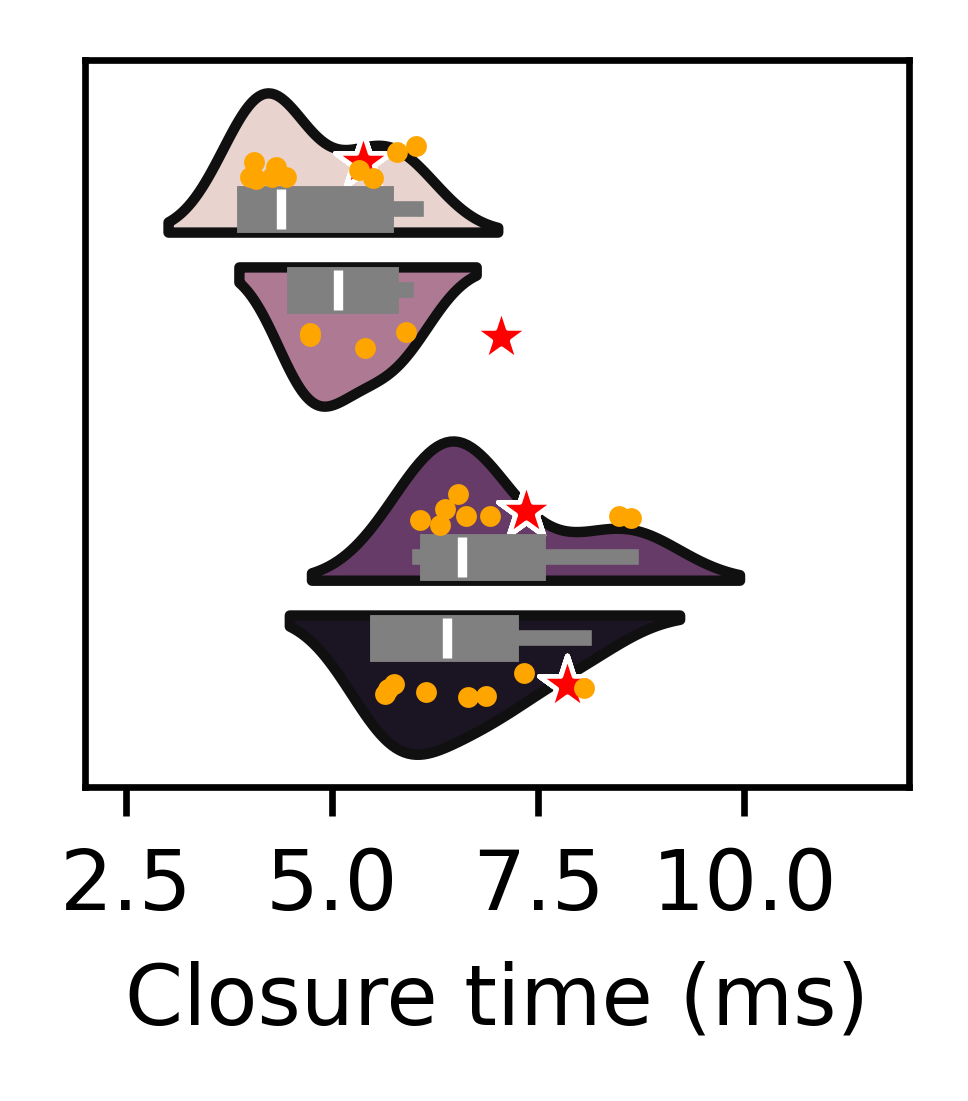

In [24]:
closure_time_for_velocity_1 = closure_data[closure_data["velocity"] == 1]["Closure time (ms)"].values[0]
waiting_time_custom_palette = ["#edd0ca", "#b77093","#6e346e","#191125"]
# plot histogram of closure time for velocity 1 colored by substrate type
keys_in_sorted_order = {"cryochip":0, "newSiChip":1, "si_old_chip":2, "autogrid":3}
closure_data_sorted = closure_data[closure_data["velocity"] == 1]
closure_data_sorted["order"] = closure_data_sorted["substrate"].map(keys_in_sorted_order)
closure_data_sorted = closure_data_sorted.sort_values(by="order")

#with temporary_rcparams(rcParams):
plt.figure(figsize=figsize_in, dpi=600)
# sort data according to mean closure time for velocity 1 for each substrate in a new df 
#closure_data_sorted = closure_data[closure_data["velocity"] == 1].sort_values(by="Closure time (ms)")

vp = sns.violinplot(\
    data=closure_data_sorted[closure_data_sorted["velocity"] == 1], \
    x="Closure time (ms)", y="substrate", hue="substrate", \
    split=True, orient="h", inner="box", \
    palette=waiting_time_custom_palette
)
for artist in vp.artists:  # This works for boxplot, not violinplot
    artist.set_facecolor("#edd0ca")
for line in vp.lines:
    line.set_color("grey")  # change to your desired color
sns.stripplot(data=closure_data_sorted[closure_data_sorted["velocity"] == 1], x="Closure time (ms)", y="substrate", color='orange', alpha=1, jitter=True, size=2.5, legend=False)
sns.scatterplot(data=closure_data_sorted[closure_data_sorted["velocity"] == 1], x="Expected pinch-off time (ms)", y="substrate", color='red', marker='*', s=50, label='Expected Pinch-off Time', legend=False)
#    plt.title('Closure Time Distribution for Velocity 1')
# hide y axis label and ticks
plt.yticks([])
plt.xticks([2.5, 5, 7.5, 10])
plt.xlim(2, 12)
plt.ylabel("")

plt.savefig(os.path.join(output_folder, "closure_time_distribution_velocity_1mps_anisotropy_corrected.pdf"), bbox_inches='tight')

In [27]:
# number of data points for each substrate at velocity 1
for substrate in substrates:
    count = len(closure_data_sorted[(closure_data_sorted["velocity"] == 1) & (closure_data_sorted["substrate"] == substrate)])
    print(f"Number of data points for {substrate} at velocity 1 m/s: {count}")

total_data_points = len(closure_data_sorted)
print(f"Total data points at velocity 1 m/s: {total_data_points}")

Number of data points for autogrid at velocity 1 m/s: 8
Number of data points for cryochip at velocity 1 m/s: 10
Number of data points for newSiChip at velocity 1 m/s: 4
Number of data points for si_old_chip at velocity 1 m/s: 8
Total data points at velocity 1 m/s: 30


In [32]:
closure_data[(closure_data["substrate"] == "autogrid") & (closure_data["velocity"] == 1.0)]

,substrate,velocity,trial,calibrated_depth_minimum,calibrated_depth_maximum,calibrated_height,relative_depth,relative_depth_maximum,froude_number_diameter,froude_number_thickness,relative_depth_minimum,relative_depth_range,Closure time (s),Closure time (ms),Expected pinch-off time (ms)
6,autogrid,1.0,0,0.005865,0.007865,0.001766,3.887133,4.453385,5.372237,18.433375,3.320882,0.566251,0.006865,6.864678,7.854686
7,autogrid,1.0,1,0.007060,0.009060,0.001766,4.563828,5.130079,5.372237,18.433375,3.997576,0.566251,0.008060,8.059720,7.854686
8,autogrid,1.0,2,0.004682,0.006682,0.001766,3.217317,3.783569,5.372237,18.433375,2.651066,0.566251,0.005682,5.681782,7.854686
9,autogrid,1.0,3,0.004750,0.006750,0.001766,3.255674,3.821926,5.372237,18.433375,2.689423,0.566251,0.005750,5.749520,7.854686
10,autogrid,1.0,4,0.004636,0.006636,0.001766,3.191124,3.757375,5.372237,18.433375,2.624872,0.566251,0.005636,5.635525,7.854686
11,autogrid,1.0,5,0.005646,0.007646,0.001766,3.763201,4.329452,5.372237,18.433375,3.196949,0.566251,0.006646,6.645813,7.854686
12,autogrid,1.0,6,0.005134,0.007134,0.001766,3.473239,4.039490,5.372237,18.433375,2.906987,0.566251,0.006134,6.133740,7.854686
13,autogrid,1.0,7,0.006323,0.008323,0.001766,4.146748,4.712999,5.372237,18.433375,3.580496,0.566251,0.007323,7.323157,7.854686


In [33]:
# save data for closure time for velocity 1
closure_time_data = closure_data[closure_data["velocity"] == 1][["substrate", "Closure time (ms)"]]
closure_time_data.to_csv(os.path.join(output_folder, "closure_time_for_velocity_1_corrected.csv"), index=False)
closure_time_data.head()

,substrate,Closure time (ms)
6,autogrid,6.864678
7,autogrid,8.059720
8,autogrid,5.681782
9,autogrid,5.749520
10,autogrid,5.635525


In [34]:
mean_time_cryochip = closure_time_data[closure_time_data['substrate'] == 'cryochip']['Closure time (ms)'].mean()
mean_time_cryosilico = closure_time_data[closure_time_data['substrate'] == 'newSiChip']['Closure time (ms)'].mean()
mean_time_si_old_chip = closure_time_data[closure_time_data['substrate'] == 'si_old_chip']['Closure time (ms)'].mean()
mean_time_autogrid = closure_time_data[closure_time_data['substrate'] == 'autogrid']['Closure time (ms)'].mean()

std_time_cryochip = closure_time_data[closure_time_data['substrate'] == 'cryochip']['Closure time (ms)'].std()
std_time_cryosilico = closure_time_data[closure_time_data['substrate'] == 'newSiChip']['Closure time (ms)'].std()
std_time_si_old_chip = closure_time_data[closure_time_data['substrate'] == 'si_old_chip']['Closure time (ms)'].std()
std_time_autogrid = closure_time_data[closure_time_data['substrate'] == 'autogrid']['Closure time (ms)'].std()
print(f"Mean closure time for cryochip: {mean_time_cryochip:.2f} ms ± {std_time_cryochip:.2f} ms")
print(f"Mean closure time for cryosilico: {mean_time_cryosilico:.2f} ms ± {std_time_cryosilico:.2f} ms")
print(f"Mean closure time for si_old_chip: {mean_time_si_old_chip:.2f} ms ± {std_time_si_old_chip:.2f} ms")
print(f"Mean closure time for autogrid: {mean_time_autogrid:.2f} ms ± {std_time_autogrid:.2f} ms")




Mean closure time for cryochip: 4.78 ms ± 0.79 ms
Mean closure time for cryosilico: 5.19 ms ± 0.57 ms
Mean closure time for si_old_chip: 6.99 ms ± 1.00 ms
Mean closure time for autogrid: 6.51 ms ± 0.88 ms
